<a href="https://colab.research.google.com/github/HarshRaj3112007/100-Days-of-ML/blob/main/outlier_removal_using_percentile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('weight-height.csv')

In [3]:
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


<Axes: xlabel='Height', ylabel='Density'>

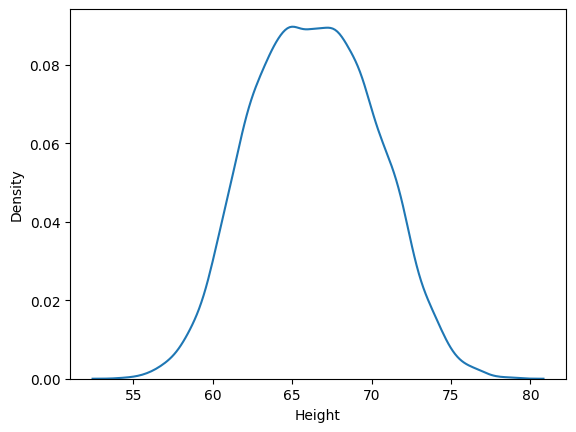

In [4]:
sns.kdeplot(df['Height'])

Approx Normal

<Axes: ylabel='Height'>

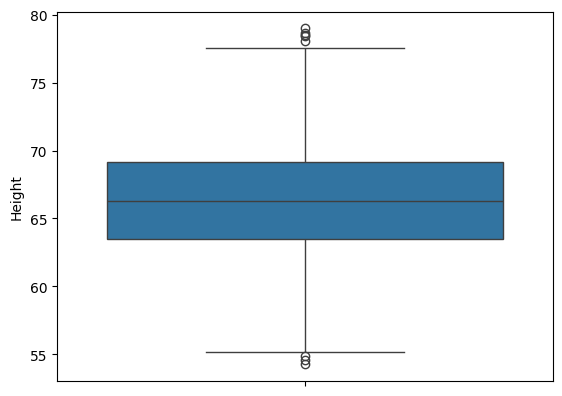

In [7]:
sns.boxplot(df['Height'])

In [6]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


In [9]:
ulimit = df['Height'].quantile(0.975)
llimit = df['Height'].quantile(0.05)

In [10]:
print(ulimit,llimit)

73.6970884216877 60.24622082610544


# Trimming

In [11]:
new_df = df[(df['Height'] <= 73.7) & (df['Height'] >= 60.24)]

In [12]:
new_df['Height'].describe()

,Height
count,9253.000000
mean,66.535921
std,3.311729
min,60.243359
25%,63.865018
50%,66.449608
75%,69.104803
max,73.696859


In [13]:
new_df

,Gender,Height,Weight
1,Male,68.781904,162.310473
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
5,Male,67.253016,152.212156
6,Male,68.785081,183.927889
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


<Axes: xlabel='Height', ylabel='Density'>

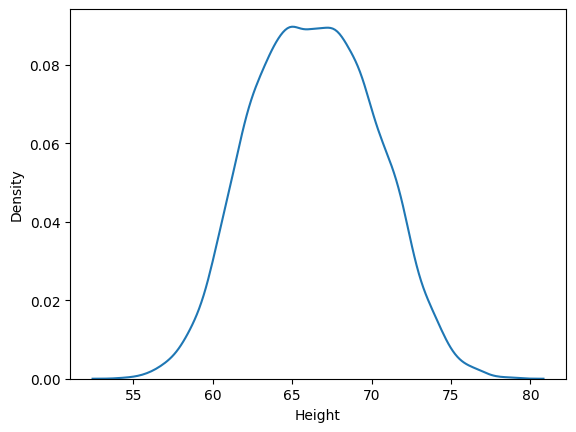

In [14]:
sns.kdeplot(df['Height'])

<Axes: xlabel='Height', ylabel='Density'>

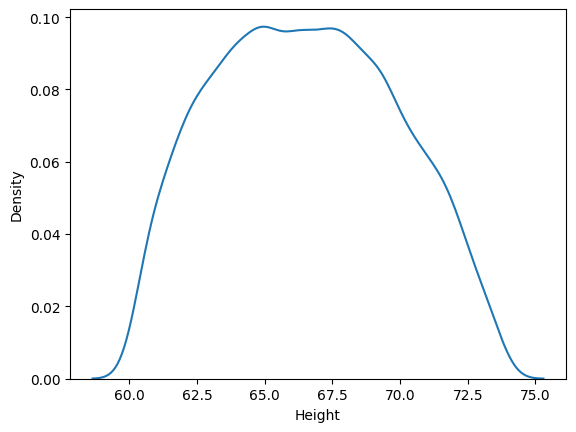

In [15]:
sns.kdeplot(new_df['Height'])

<Axes: ylabel='Height'>

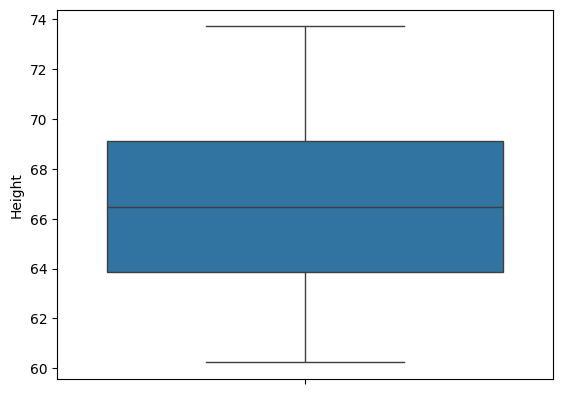

In [16]:
sns.boxplot(new_df['Height'])

# Capping -> Winsorization


In [17]:
df['Height'] = np.where(df['Height'] >= ulimit,
        ulimit,
        np.where(df['Height'] <= llimit,
        llimit,
        df['Height']))

# Alternative code for same task

In [22]:
df['Height'] = df['Height'].clip(lower=llimit, upper=ulimit)

In [18]:
df

,Gender,Height,Weight
0,Male,73.697088,241.893563
1,Male,68.781904,162.310473
2,Male,73.697088,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [21]:
df.shape

(10000, 3)

<Axes: ylabel='Height'>

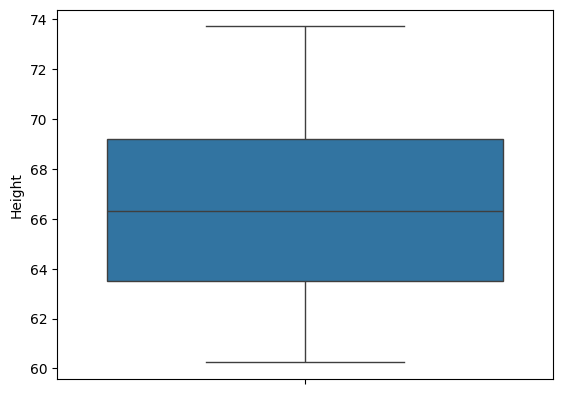

In [19]:
sns.boxplot(df['Height'])

/tmp/ipykernel_356/3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

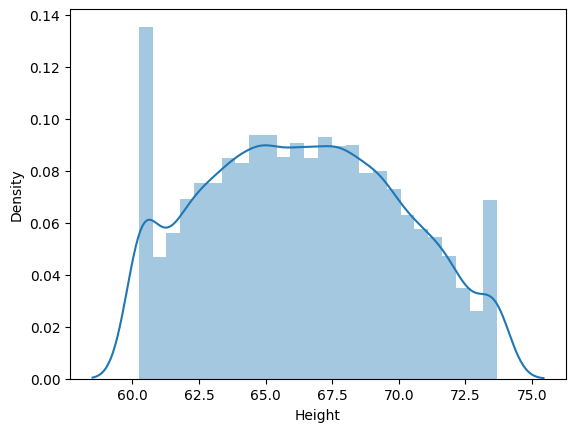

In [20]:
sns.distplot(df['Height'])